<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


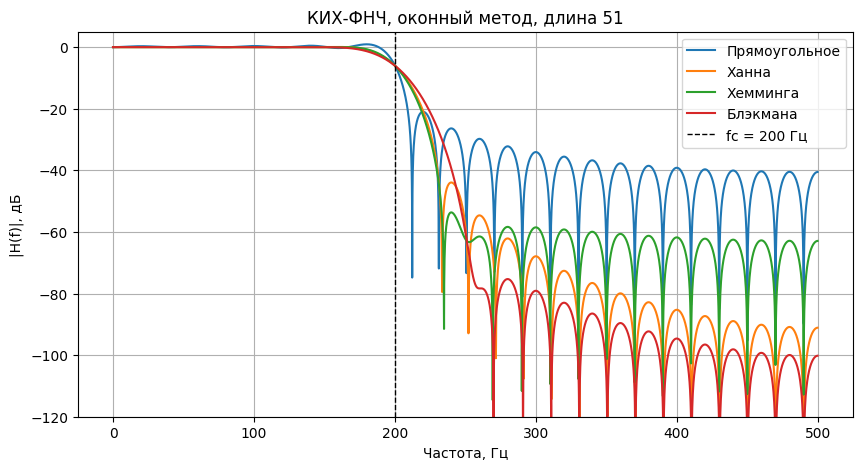

,Окно,"Пульсации в ПП, дБ","Макс. уровень в ПЗ, дБ","Подавление в ПЗ, дБ"
0,Прямоугольное,0.56,-29.77,29.77
1,Ханна,0.03,-54.63,54.63
2,Хемминга,0.03,-58.36,58.36
3,Блэкмана,0.01,-60.09,60.09


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
import warnings

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

def db(x):
    # Амплитуда в дБ с защитой от log(0).
    return 20 * np.log10(np.maximum(np.abs(x), 1e-12))

def amp_spectrum(x, fs):
    # Односторонний амплитудный спектр.
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    amp = 2 * np.abs(np.fft.rfft(x)) / n
    return freqs, amp

def amp_at(x, fs, f0):
    freqs, amp = amp_spectrum(x, fs)
    return amp[np.argmin(np.abs(freqs - f0))]

def show_freq_response(b, a=1, fs=1000, label=None, worN=4096):
    w, h = signal.freqz(b, a, worN=worN, fs=fs)
    plt.plot(w, db(h), label=label)
    return w, h

# Параметры задачи
fs = 1000
fc = 200
numtaps = 51
windows = {
    "Прямоугольное": "boxcar",
    "Ханна": "hann",
    "Хемминга": "hamming",
    "Блэкмана": "blackman",
}

fir_by_window = {}
rows = []

plt.figure()
for name, win in windows.items():
    b = signal.firwin(numtaps, fc, window=win, fs=fs)
    fir_by_window[name] = b
    w, h = show_freq_response(b, fs=fs, label=name)

    Hdb = db(h)
    passband = w <= 150
    stopband = w >= 250
    rows.append({
        "Окно": name,
        "Пульсации в ПП, дБ": np.max(Hdb[passband]) - np.min(Hdb[passband]),
        "Макс. уровень в ПЗ, дБ": np.max(Hdb[stopband]),
        "Подавление в ПЗ, дБ": -np.max(Hdb[stopband]),
    })

plt.axvline(fc, color="k", linestyle="--", linewidth=1, label="fc = 200 Гц")
plt.title("КИХ-ФНЧ, оконный метод, длина 51")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-120, 5)
plt.legend()
plt.show()

display(pd.DataFrame(rows).round(2))


**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

**Ответ:** Наилучшее подавление в полосе заграждения даёт окно Блэкмана: у него самые низкие боковые лепестки. Самая крутая переходная полоса получается у прямоугольного окна, потому что у него самая узкая главная лепестковая область. Но это достигается ценой больших боковых лепестков, то есть худшего подавления в полосе заграждения. Окна Ханна и Хемминга дают компромисс: переходная полоса шире, зато боковые лепестки заметно меньше


### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


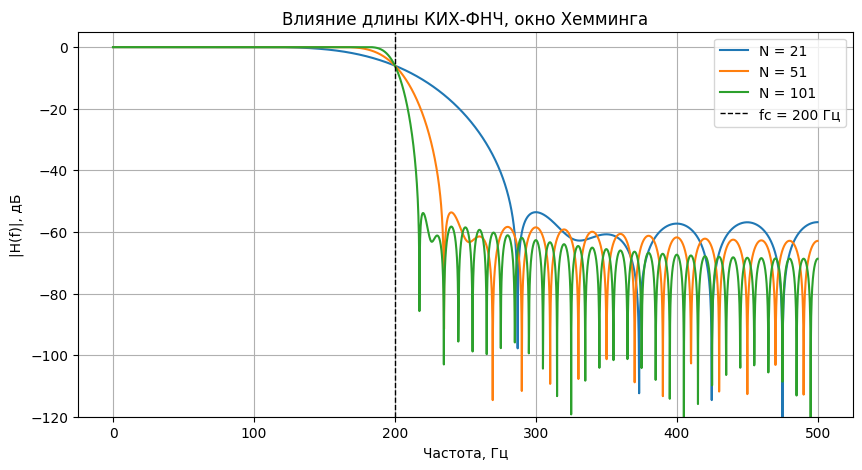

,Длина,"Пульсации в ПП, дБ","Макс. уровень в ПЗ, дБ","Подавление в ПЗ, дБ"
0,21,0.71,-22.13,22.13
1,51,0.03,-58.36,58.36
2,101,0.02,-58.52,58.52


In [2]:
fs = 1000
fc = 200
lengths = [21, 51, 101]
hamming_by_length = {}
rows = []

plt.figure()
for n in lengths:
    b = signal.firwin(n, fc, window="hamming", fs=fs)
    hamming_by_length[n] = b
    w, h = show_freq_response(b, fs=fs, label=f"N = {n}")

    Hdb = db(h)
    passband = w <= 150
    stopband = w >= 250
    rows.append({
        "Длина": n,
        "Пульсации в ПП, дБ": np.max(Hdb[passband]) - np.min(Hdb[passband]),
        "Макс. уровень в ПЗ, дБ": np.max(Hdb[stopband]),
        "Подавление в ПЗ, дБ": -np.max(Hdb[stopband]),
    })

plt.axvline(fc, color="k", linestyle="--", linewidth=1, label="fc = 200 Гц")
plt.title("Влияние длины КИХ-ФНЧ, окно Хемминга")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-120, 5)
plt.legend()
plt.show()

display(pd.DataFrame(rows).round(2))


**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

**Ответ:** При увеличении длины фильтра переходная полоса становится уже, поэтому срез получается круче. Уровень боковых лепестков в основном определяется типом окна, поэтому для одного и того же окна Хемминга он меняется не так сильно. Однако на фиксированной частоте в полосе заграждения подавление обычно становится лучше, потому что эта частота оказывается дальше от всё более узкой переходной области


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


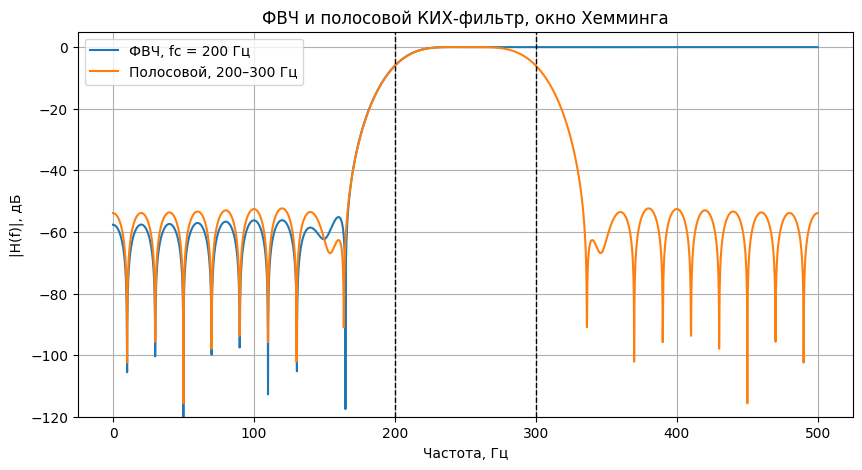

In [3]:
fs = 1000
numtaps = 51

b_hp = signal.firwin(numtaps, 200, pass_zero=False, window="hamming", fs=fs)
b_bp = signal.firwin(numtaps, [200, 300], pass_zero=False, window="hamming", fs=fs)

plt.figure()
show_freq_response(b_hp, fs=fs, label="ФВЧ, fc = 200 Гц")
show_freq_response(b_bp, fs=fs, label="Полосовой, 200–300 Гц")
plt.axvline(200, color="k", linestyle="--", linewidth=1)
plt.axvline(300, color="k", linestyle="--", linewidth=1)
plt.title("ФВЧ и полосовой КИХ-фильтр, окно Хемминга")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-120, 5)
plt.legend()
plt.show()


Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

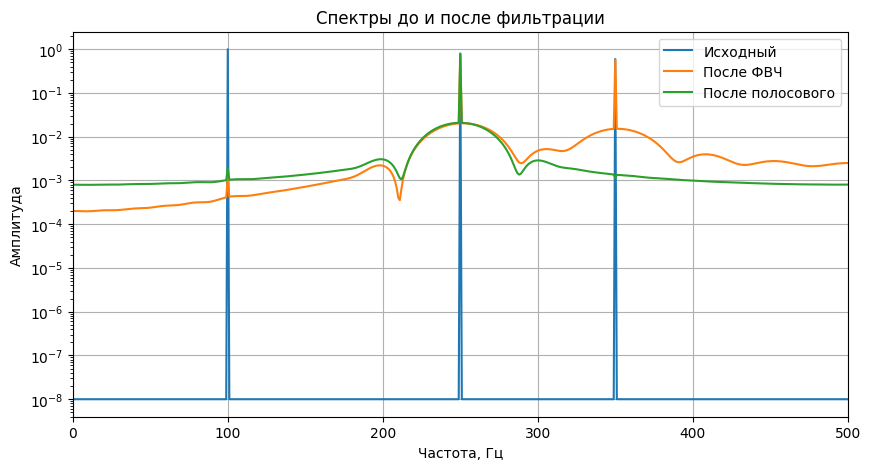

,Сигнал,100 Гц,250 Гц,350 Гц
0,Исходный,1.0000,0.8000,0.6000
1,После ФВЧ,0.0012,0.7798,0.5848
2,После полосового,0.0019,0.7792,0.0011


In [4]:
fs = 1000
duration = 1.0
t = np.arange(0, duration, 1/fs)

x = (
    1.0 * np.sin(2*np.pi*100*t) +
    0.8 * np.sin(2*np.pi*250*t) +
    0.6 * np.sin(2*np.pi*350*t)
)

y_hp = signal.lfilter(b_hp, [1], x)
y_bp = signal.lfilter(b_bp, [1], x)

plt.figure()
for sig, label in [(x, "Исходный"), (y_hp, "После ФВЧ"), (y_bp, "После полосового")]:
    f, a = amp_spectrum(sig, fs)
    plt.semilogy(f, np.maximum(a, 1e-8), label=label)

plt.title("Спектры до и после фильтрации")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.xlim(0, 500)
plt.legend()
plt.show()

rows = []
for label, sig in [("Исходный", x), ("После ФВЧ", y_hp), ("После полосового", y_bp)]:
    rows.append({
        "Сигнал": label,
        "100 Гц": amp_at(sig, fs, 100),
        "250 Гц": amp_at(sig, fs, 250),
        "350 Гц": amp_at(sig, fs, 350),
    })
display(pd.DataFrame(rows).round(4))


**Вопрос:** Объясните полученные результаты.

**Ответ:** ФВЧ с частотой среза 200 Гц подавляет низкочастотную составляющую 100 Гц и пропускает компоненты 250 и 350 Гц. Полосовой фильтр 200-300 Гц оставляет в основном составляющую 250 Гц, а 100 и 350 Гц подавляет. Небольшие остаточные пики связаны с конечной длиной КИХ-фильтра и ненулевыми боковыми лепестками окна Хемминга


## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

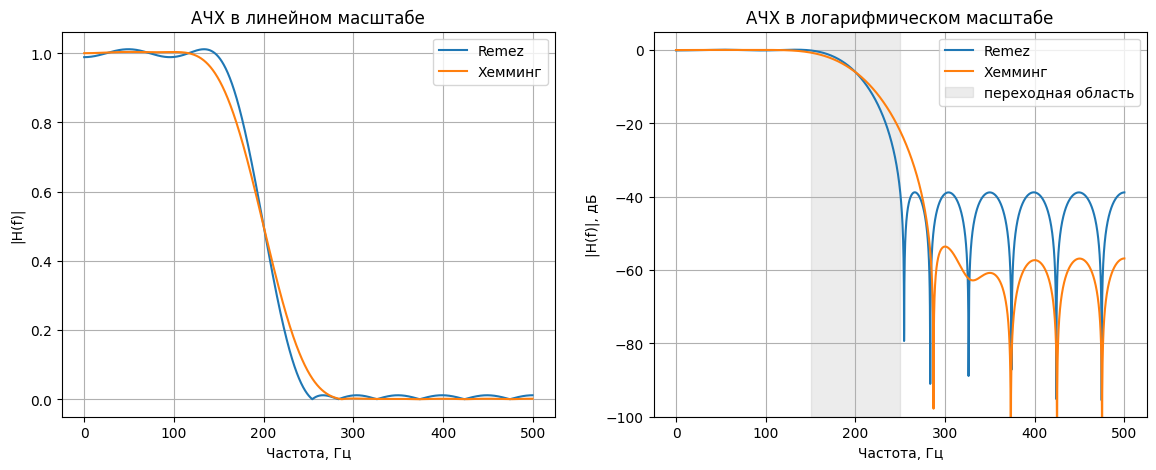

,Фильтр,"Пульсации ПП 0–150 Гц, дБ","Макс. уровень ПЗ 250–500 Гц, дБ","Подавление ПЗ, дБ"
0,Remez,0.20,-38.79,38.79
1,Хемминг,0.71,-22.13,22.13


In [ ]:
fs = 1000
numtaps = 21

b_remez_21 = signal.remez(numtaps, [0, 150, 250, fs/2], [1, 0], fs=fs)
b_hamming_21 = signal.firwin(numtaps, 200, window="hamming", fs=fs)

w_remez, h_remez = signal.freqz(b_remez_21, worN=4096, fs=fs)
w_hamming, h_hamming = signal.freqz(b_hamming_21, worN=4096, fs=fs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(w_remez, np.abs(h_remez), label="Remez")
axes[0].plot(w_hamming, np.abs(h_hamming), label="Хемминг")
axes[0].set_title("АЧХ в линейном масштабе")
axes[0].set_xlabel("Частота, Гц")
axes[0].set_ylabel("|H(f)|")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(w_remez, db(h_remez), label="Remez")
axes[1].plot(w_hamming, db(h_hamming), label="Хемминг")
axes[1].axvspan(150, 250, color="gray", alpha=0.15, label="переходная область")
axes[1].set_title("АЧХ в логарифмическом масштабе")
axes[1].set_xlabel("Частота, Гц")
axes[1].set_ylabel("|H(f)|, дБ")
axes[1].set_ylim(-100, 5)
axes[1].legend()
axes[1].grid(True)

plt.show()

rows = []
for name, w, h in [
    ("Remez", w_remez, h_remez),
    ("Хемминг", w_hamming, h_hamming),
]:
    Hdb = db(h)
    rows.append({
        "Фильтр": name,
        "Пульсации ПП 0–150 Гц, дБ": np.max(Hdb[w <= 150]) - np.min(Hdb[w <= 150]),
        "Макс. уровень ПЗ 250–500 Гц, дБ": np.max(Hdb[w >= 250]),
        "Подавление ПЗ, дБ": -np.max(Hdb[w >= 250]),
    })
display(pd.DataFrame(rows).round(2))



**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

**Ответ:** При одинаковой длине фильтр Паркса-МакКлеллана remez имеет более крутой срез и лучшее подавление в заданной полосе заграждения 250-500 Гц. Пульсации у него равноволновые: они специально распределяются по полосе пропускания и полосе заграждения. У оконного фильтра Хемминга пульсации в полосе пропускания более гладкие, но переходная область шире и подавление в заданной ПЗ хуже


### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


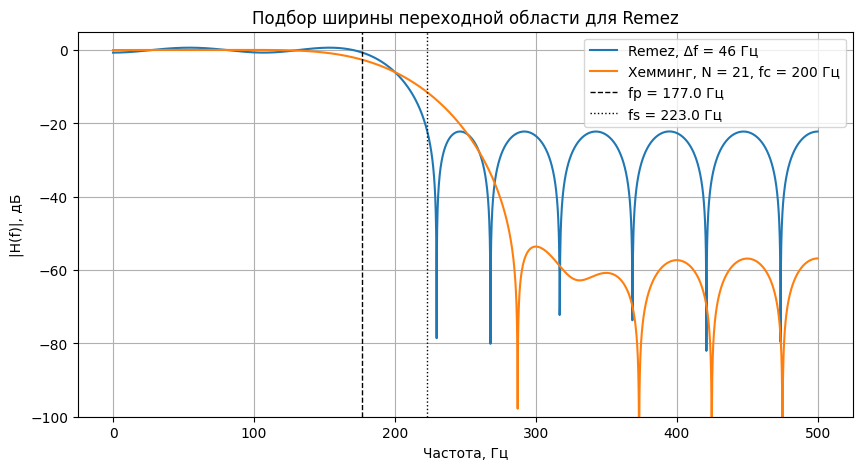

Целевой максимум в ПЗ для Хемминга: -22.13 дБ
Лучшее совпадение: Δf = 46 Гц, fp = 177.0 Гц, fs = 223.0 Гц
Максимум в ПЗ для Remez: -22.20 дБ


In [ ]:
fs = 1000
numtaps = 21

# Целевой уровень: оконный фильтр Хемминга из задачи 2.1 в полосе 250–500 Гц
target_stop_db = np.max(db(h_hamming)[w_hamming >= 250])

candidates = []
for width in np.arange(20, 181, 1):
    fp = 200 - width/2      # верхняя частота ПП
    fsb = 200 + width/2     # нижняя частота ПЗ
    try:
        b = signal.remez(numtaps, [0, fp, fsb, fs/2], [1, 0], fs=fs, maxiter=1000)
        w, h = signal.freqz(b, worN=8192, fs=fs)
        stop_db = np.max(db(h)[w >= fsb])
        candidates.append((abs(stop_db - target_stop_db), width, fp, fsb, stop_db, b))
    except Exception:
        pass

best_diff, best_width, best_fp, best_fsb, best_stop_db, b_best_width = min(candidates, key=lambda x: x[0])
w_best, h_best = signal.freqz(b_best_width, worN=4096, fs=fs)

plt.figure()
plt.plot(w_best, db(h_best), label=f"Remez, Δf = {best_width:.0f} Гц")
plt.plot(w_hamming, db(h_hamming), label="Хемминг, N = 21, fc = 200 Гц")
plt.axvline(best_fp, color="k", linestyle="--", linewidth=1, label=f"fp = {best_fp:.1f} Гц")
plt.axvline(best_fsb, color="k", linestyle=":", linewidth=1, label=f"fs = {best_fsb:.1f} Гц")
plt.title("Подбор ширины переходной области для Remez")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-100, 5)
plt.legend()
plt.show()

print(f"Целевой максимум в ПЗ для Хемминга: {target_stop_db:.2f} дБ")
print(f"Лучшее совпадение: Δf = {best_width:.0f} Гц, fp = {best_fp:.1f} Гц, fs = {best_fsb:.1f} Гц")
print(f"Максимум в ПЗ для Remez: {best_stop_db:.2f} дБ")


**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

**Ответ:** При выбранной сетке подбора совпадение получилось примерно при ширине переходной области 46 Гц: верхняя граница полосы пропускания около 177 Гц, нижняя граница полосы заграждения около 223 Гц. При более широкой переходной области равноволновой фильтр подавляет полосу заграждения сильнее, при более узкой - слабее


### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


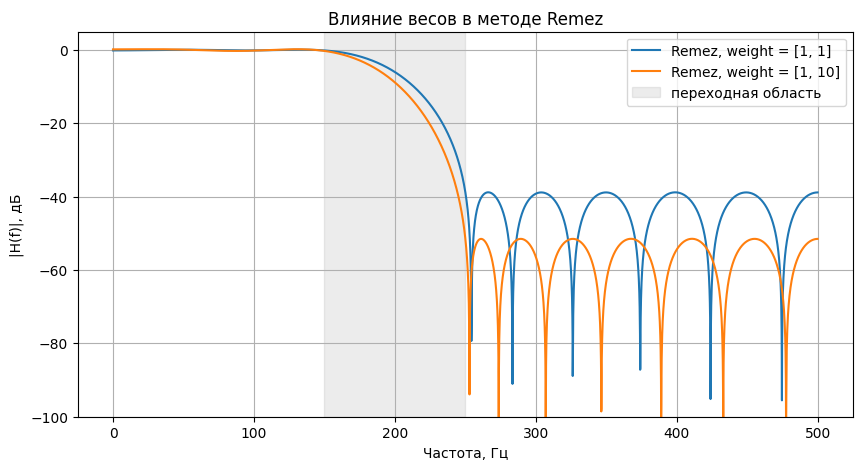

,Фильтр,"Пульсации ПП, дБ","Макс. уровень ПЗ, дБ","Подавление ПЗ, дБ"
0,"weight = [1, 1]",0.20,-38.79,38.79
1,"weight = [1, 10]",0.46,-51.47,51.47


In [ ]:
fs = 1000
numtaps = 21

b_remez_weighted = signal.remez(
    numtaps,
    [0, 150, 250, fs/2],
    [1, 0],
    weight=[1, 10],
    fs=fs
)

w_norm, h_norm = signal.freqz(b_remez_21, worN=4096, fs=fs)
w_weighted, h_weighted = signal.freqz(b_remez_weighted, worN=4096, fs=fs)

plt.figure()
plt.plot(w_norm, db(h_norm), label="Remez, weight = [1, 1]")
plt.plot(w_weighted, db(h_weighted), label="Remez, weight = [1, 10]")
plt.axvspan(150, 250, color="gray", alpha=0.15, label="переходная область")
plt.title("Влияние весов в методе Remez")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-100, 5)
plt.legend()
plt.show()

rows = []
for name, w, h in [
    ("weight = [1, 1]", w_norm, h_norm),
    ("weight = [1, 10]", w_weighted, h_weighted),
]:
    Hdb = db(h)
    rows.append({
        "Фильтр": name,
        "Пульсации ПП, дБ": np.max(Hdb[w <= 150]) - np.min(Hdb[w <= 150]),
        "Макс. уровень ПЗ, дБ": np.max(Hdb[w >= 250]),
        "Подавление ПЗ, дБ": -np.max(Hdb[w >= 250]),
    })
display(pd.DataFrame(rows).round(2))


**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

**Ответ:** При weight=[1, 10] ошибка в полосе заграждения штрафуется сильнее, поэтому подавление в ПЗ увеличивается. Цена этого - рост пульсаций в полосе пропускания: фильтр хуже сохраняет ровную амплитуду полезных низких частот.


### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


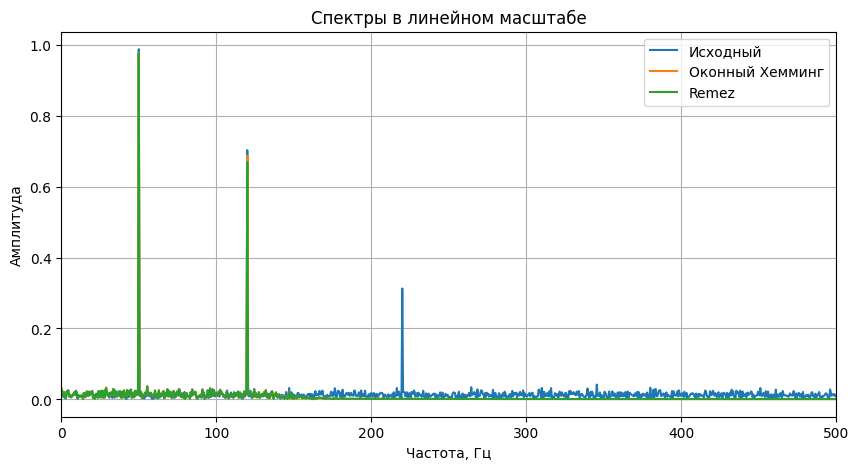

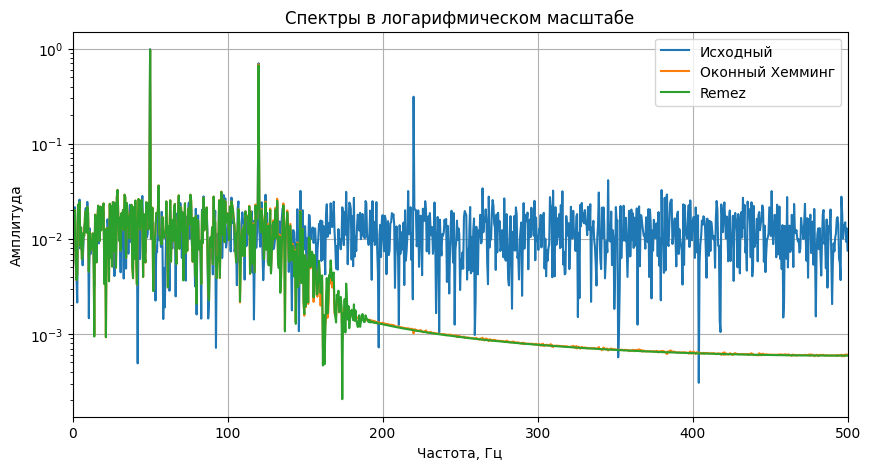

,Сигнал,50 Гц,120 Гц,220 Гц
0,Исходный,0.9881,0.7032,0.3127
1,Оконный Хемминг,0.9781,0.6874,0.0010
2,Remez,0.9766,0.6697,0.0011


Оконный Хемминг: амплитуда 120 Гц изменилась на -0.0158
Remez: амплитуда 120 Гц изменилась на -0.0335


In [ ]:
fs = 1000
duration = 2.0
t = np.arange(0, duration, 1/fs)

np.random.seed(42)
x = (
    1.0 * np.sin(2*np.pi*50*t) +
    0.7 * np.sin(2*np.pi*120*t) +
    0.3 * np.sin(2*np.pi*220*t) +
    np.sqrt(0.1) * np.random.randn(len(t))
)

b_win_51 = signal.firwin(51, 150, window="hamming", fs=fs)
b_remez_51 = signal.remez(51, [0, 100, 200, fs/2], [1, 0], fs=fs)

y_win = signal.lfilter(b_win_51, [1], x)
y_remez = signal.lfilter(b_remez_51, [1], x)

signals = [
    ("Исходный", x),
    ("Оконный Хемминг", y_win),
    ("Remez", y_remez),
]

plt.figure()
for label, sig in signals:
    f, a = amp_spectrum(sig, fs)
    plt.plot(f, a, label=label)
plt.title("Спектры в линейном масштабе")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.xlim(0, 500)
plt.legend()
plt.show()

plt.figure()
for label, sig in signals:
    f, a = amp_spectrum(sig, fs)
    plt.semilogy(f, np.maximum(a, 1e-8), label=label)
plt.title("Спектры в логарифмическом масштабе")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.xlim(0, 500)
plt.legend()
plt.show()

rows = []
for label, sig in signals:
    rows.append({
        "Сигнал": label,
        "50 Гц": amp_at(sig, fs, 50),
        "120 Гц": amp_at(sig, fs, 120),
        "220 Гц": amp_at(sig, fs, 220),
    })

amp_table = pd.DataFrame(rows)
display(amp_table.round(4))

input_120 = amp_table.loc[amp_table["Сигнал"] == "Исходный", "120 Гц"].iloc[0]
for label in ["Оконный Хемминг", "Remez"]:
    out_120 = amp_table.loc[amp_table["Сигнал"] == label, "120 Гц"].iloc[0]
    print(f"{label}: амплитуда 120 Гц изменилась на {out_120 - input_120:.4f}")


**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


**Ответ:** Remez лучше подавляет составляющую 220 Гц и высокочастотный шум, потому что его полоса заграждения явно начинается с 200 Гц и оптимизируется равноволновым методом. Компоненту 120 Гц лучше сохраняет оконный фильтр Хемминга: при fc=150 Гц эта частота ещё находится в полосе пропускания, а для Remez с полосой пропускания 0-100 Гц частота 120 Гц уже попадает в переходную область. По расчёту в таблице амплитуда 120 Гц уменьшается у оконного фильтра примерно на 0.016, у Remez - примерно на 0.034 относительно исходного сигнала


## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


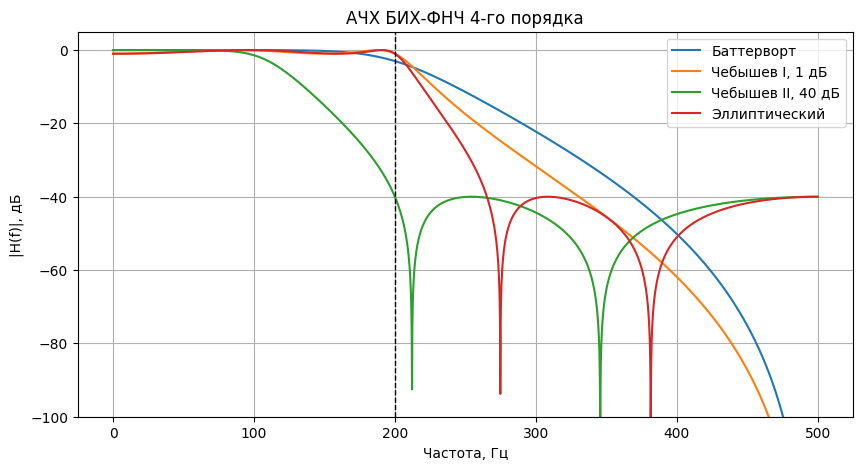

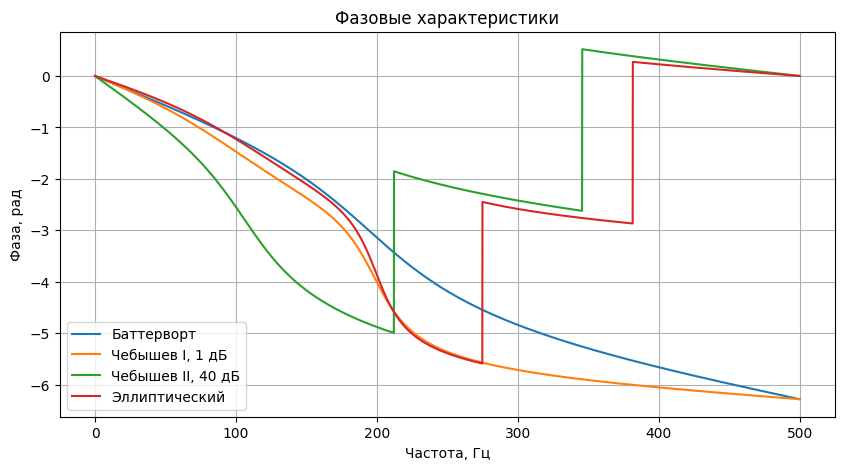

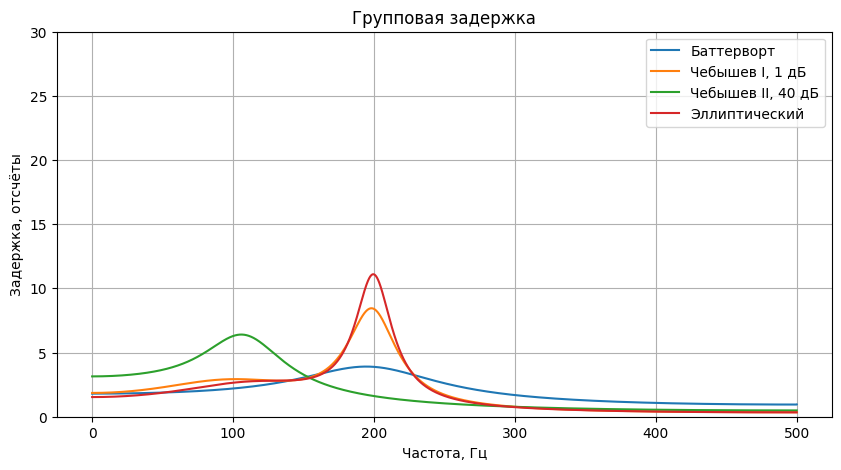

,Фильтр,"Средняя ГЗ в ПП, отсч.","Разброс ГЗ в ПП, отсч."
0,Баттерворт,2.347,0.582
1,"Чебышев I, 1 дБ",2.729,0.669
2,"Чебышев II, 40 дБ",4.113,1.238
3,Эллиптический,2.472,0.755


In [5]:
fs = 1000
fc = 200
order = 4

iir_filters = {
    "Баттерворт": signal.butter(order, fc, btype="low", fs=fs, output="sos"),
    "Чебышев I, 1 дБ": signal.cheby1(order, 1, fc, btype="low", fs=fs, output="sos"),
    "Чебышев II, 40 дБ": signal.cheby2(order, 40, fc, btype="low", fs=fs, output="sos"),
    "Эллиптический": signal.ellip(order, 1, 40, fc, btype="low", fs=fs, output="sos"),
}

plt.figure()
for name, sos in iir_filters.items():
    w, h = signal.sosfreqz(sos, worN=4096, fs=fs)
    plt.plot(w, db(h), label=name)
plt.axvline(fc, color="k", linestyle="--", linewidth=1)
plt.title("АЧХ БИХ-ФНЧ 4-го порядка")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-100, 5)
plt.legend()
plt.show()

plt.figure()
for name, sos in iir_filters.items():
    w, h = signal.sosfreqz(sos, worN=4096, fs=fs)
    phase = np.unwrap(np.angle(h))
    plt.plot(w, phase, label=name)
plt.title("Фазовые характеристики")
plt.xlabel("Частота, Гц")
plt.ylabel("Фаза, рад")
plt.legend()
plt.show()

plt.figure()
rows = []
for name, sos in iir_filters.items():
    b, a = signal.sos2tf(sos)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        wg, gd = signal.group_delay((b, a), w=4096, fs=fs)
    plt.plot(wg, gd, label=name)
    mask = wg <= 180
    rows.append({
        "Фильтр": name,
        "Средняя ГЗ в ПП, отсч.": np.mean(gd[mask]),
        "Разброс ГЗ в ПП, отсч.": np.std(gd[mask]),
    })

plt.title("Групповая задержка")
plt.xlabel("Частота, Гц")
plt.ylabel("Задержка, отсчёты")
plt.ylim(0, 30)
plt.legend()
plt.show()

display(pd.DataFrame(rows).round(3))


**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


**Ответ:** Самый крутой спад среди фильтров 4го порядка даёт эллиптический фильтр, потому что он допускает пульсации и в полосе пропускания, и в полосе заграждения. Наименьшие фазовые искажения в полосе пропускания даёт Баттерворт: его АЧХ монотонная, а фазовая характеристика и групповая задержка обычно меняются плавнее, чем у Чебышева и эллиптического фильтра. При этом строго линейной фазы у БИХ-фильтров нет


### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


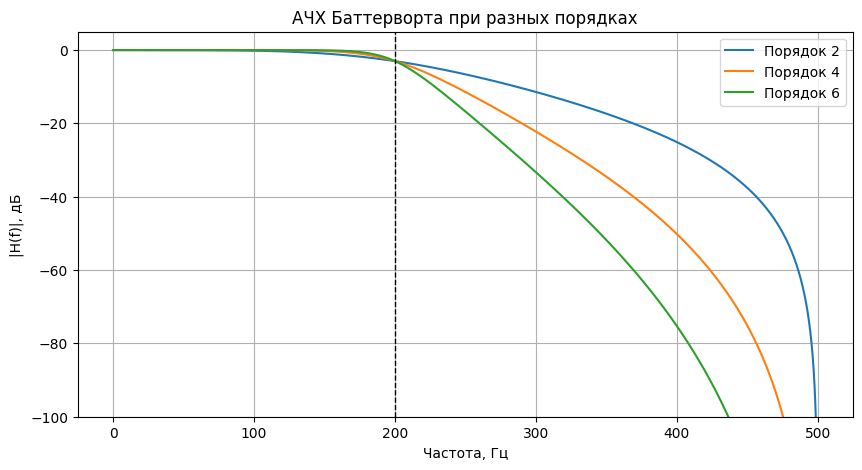

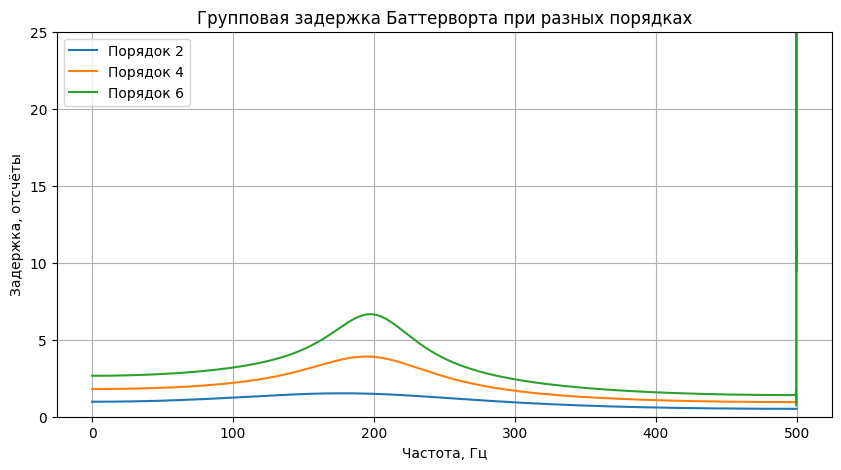

In [ ]:
fs = 1000
fc = 200
orders = [2, 4, 6]

plt.figure()
for n in orders:
    sos = signal.butter(n, fc, btype="low", fs=fs, output="sos")
    w, h = signal.sosfreqz(sos, worN=4096, fs=fs)
    plt.plot(w, db(h), label=f"Порядок {n}")
plt.axvline(fc, color="k", linestyle="--", linewidth=1)
plt.title("АЧХ Баттерворта при разных порядках")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-100, 5)
plt.legend()
plt.show()

plt.figure()
for n in orders:
    sos = signal.butter(n, fc, btype="low", fs=fs, output="sos")
    b, a = signal.sos2tf(sos)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        w, gd = signal.group_delay((b, a), w=4096, fs=fs)
    plt.plot(w, gd, label=f"Порядок {n}")
plt.title("Групповая задержка Баттерворта при разных порядках")
plt.xlabel("Частота, Гц")
plt.ylabel("Задержка, отсчёты")
plt.ylim(0, 25)
plt.legend()
plt.show()


**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

**Ответ:** При увеличении порядка Баттерворта срез становится круче, а подавление в полосе заграждения сильнее. Одновременно растёт групповая задержка и её неравномерность в полосе пропускания, особенно ближе к частоте среза. Поэтому более высокий порядок даёт лучшую частотную избирательность, но вносит более заметные фазовые и временные искажения


### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


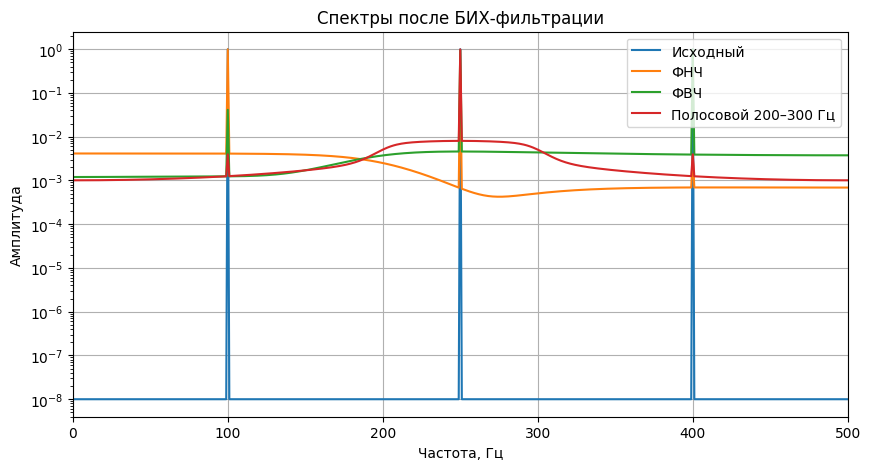

,Сигнал,100 Гц,250 Гц,400 Гц
0,Исходный,1.0000,1.0000,1.0000
1,ФНЧ,0.9967,0.2680,0.0037
2,ФВЧ,0.0412,0.9587,0.9979
3,Полосовой 200–300 Гц,0.0040,0.9920,0.0040


In [ ]:
fs = 1000
duration = 1.0
t = np.arange(0, duration, 1/fs)

x = (
    np.sin(2*np.pi*100*t) +
    np.sin(2*np.pi*250*t) +
    np.sin(2*np.pi*400*t)
)

sos_low = signal.butter(4, 200, btype="low", fs=fs, output="sos")
sos_high = signal.butter(4, 200, btype="high", fs=fs, output="sos")
sos_band = signal.butter(4, [200, 300], btype="band", fs=fs, output="sos")

filtered = [
    ("Исходный", x),
    ("ФНЧ", signal.sosfilt(sos_low, x)),
    ("ФВЧ", signal.sosfilt(sos_high, x)),
    ("Полосовой 200–300 Гц", signal.sosfilt(sos_band, x)),
]

plt.figure()
for label, sig in filtered:
    f, a = amp_spectrum(sig, fs)
    plt.semilogy(f, np.maximum(a, 1e-8), label=label)
plt.title("Спектры после БИХ-фильтрации")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.xlim(0, 500)
plt.legend()
plt.show()

rows = []
for label, sig in filtered:
    rows.append({
        "Сигнал": label,
        "100 Гц": amp_at(sig, fs, 100),
        "250 Гц": amp_at(sig, fs, 250),
        "400 Гц": amp_at(sig, fs, 400),
    })
display(pd.DataFrame(rows).round(4))


**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

**Ответ:** ФНЧ пропускает в основном 100 Гц и подавляет 250 и 400 Гц. ФВЧ подавляет 100 Гц и пропускает 250 и 400 Гц. Полосовой фильтр 200-300 Гц пропускает главным образом 250 Гц, а компоненты 100 и 400 Гц подавляет. Остаточные составляющие появляются из-за конечной крутизны фильтров и переходных процессов при фильтрации


### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


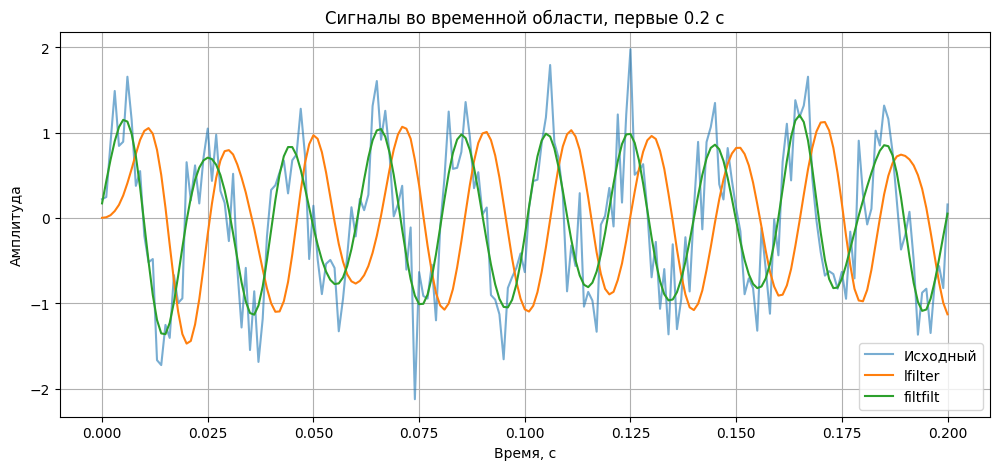

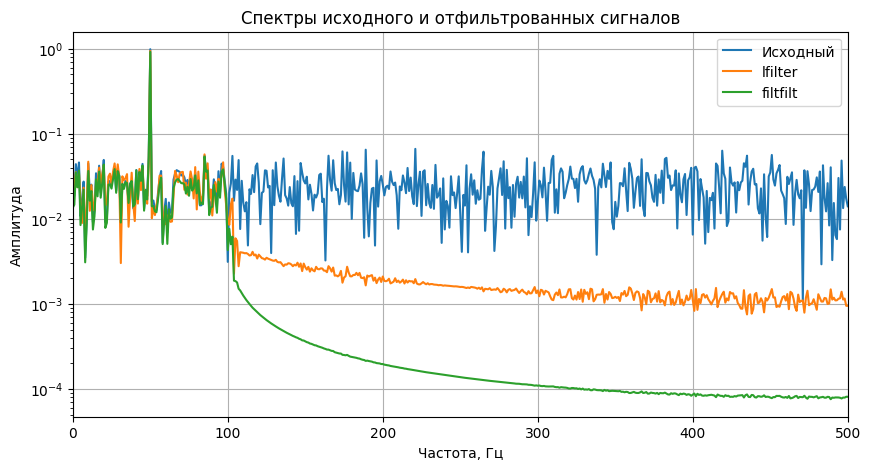

Оценка задержки lfilter относительно чистой синусоиды: 5 отсч.
Оценка задержки filtfilt относительно чистой синусоиды: 0 отсч.


In [ ]:
fs = 1000
duration = 1.0
t = np.arange(0, duration, 1/fs)

np.random.seed(42)
clean = np.sin(2*np.pi*50*t)
x = clean + np.sqrt(0.2) * np.random.randn(len(t))

b_ellip, a_ellip = signal.ellip(6, 1, 40, 100, btype="low", fs=fs)
y_lfilter = signal.lfilter(b_ellip, a_ellip, x)
y_filtfilt = signal.filtfilt(b_ellip, a_ellip, x)

plt.figure(figsize=(12, 5))
mask = t <= 0.2
plt.plot(t[mask], x[mask], label="Исходный", alpha=0.6)
plt.plot(t[mask], y_lfilter[mask], label="lfilter")
plt.plot(t[mask], y_filtfilt[mask], label="filtfilt")
plt.title("Сигналы во временной области, первые 0.2 с")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.legend()
plt.show()

plt.figure()
for label, sig in [("Исходный", x), ("lfilter", y_lfilter), ("filtfilt", y_filtfilt)]:
    f, a = amp_spectrum(sig, fs)
    plt.semilogy(f, np.maximum(a, 1e-8), label=label)
plt.title("Спектры исходного и отфильтрованных сигналов")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.xlim(0, 500)
plt.legend()
plt.show()

def lag_by_correlation(y, ref):
    y0 = y - np.mean(y)
    r0 = ref - np.mean(ref)
    corr = np.correlate(y0, r0, mode="full")
    return np.argmax(corr) - (len(ref) - 1)

print(f"Оценка задержки lfilter относительно чистой синусоиды: {lag_by_correlation(y_lfilter, clean)} отсч.")
print(f"Оценка задержки filtfilt относительно чистой синусоиды: {lag_by_correlation(y_filtfilt, clean)} отсч.")


**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

**Ответ:** filtfilt фильтрует сигнал дважды: сначала вперёд, затем назад. При обратном проходе фазовый сдвиг, внесённый прямым проходом, компенсируется. Поэтому суммарная фазовая характеристика становится нулевой, а задержка визуально исчезает


## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


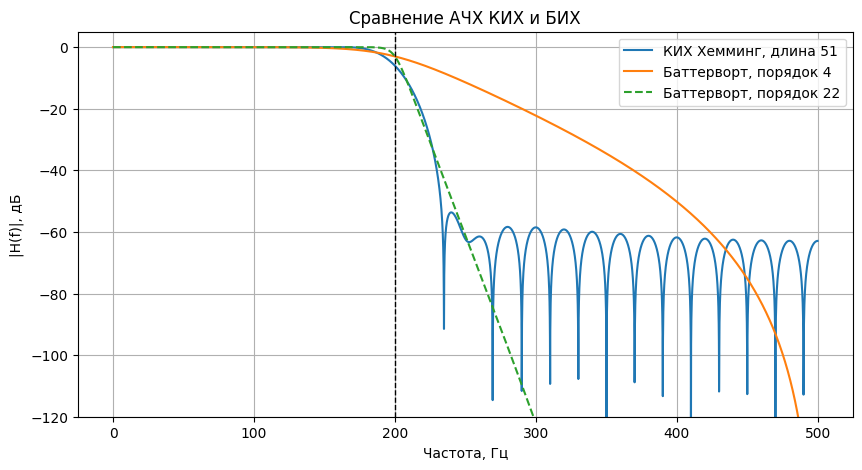

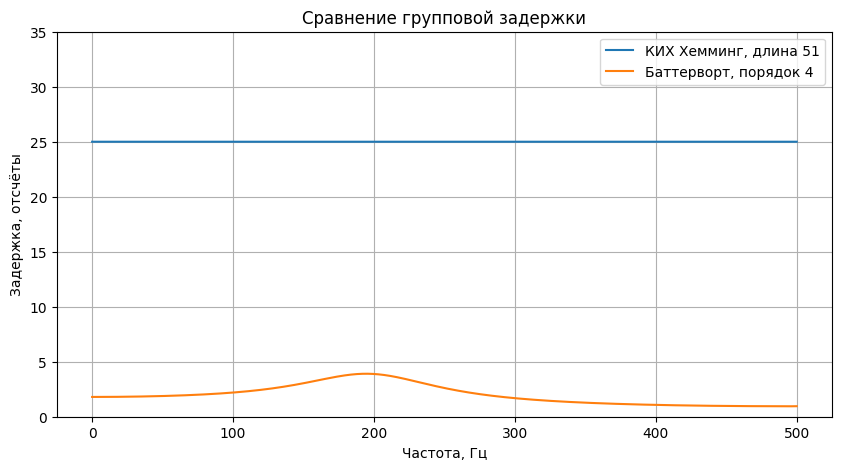

Максимальный уровень КИХ в ПЗ 250–500 Гц: -58.36 дБ
Сравнимое подавление у Баттерворта получается примерно при порядке 22.


In [ ]:
fs = 1000
fc = 200

b_fir = signal.firwin(51, fc, window="hamming", fs=fs)
sos_butter4 = signal.butter(4, fc, btype="low", fs=fs, output="sos")

w_fir, h_fir = signal.freqz(b_fir, worN=8192, fs=fs)
w_b4, h_b4 = signal.sosfreqz(sos_butter4, worN=8192, fs=fs)

# Подберём порядок Баттерворта, при котором подавление от 250 Гц
# становится сравнимым с КИХ-фильтром длины 51.
target_stop = np.max(db(h_fir)[w_fir >= 250])
matching_order = None
sos_matching = None
for n in range(1, 31):
    sos = signal.butter(n, fc, btype="low", fs=fs, output="sos")
    w_tmp, h_tmp = signal.sosfreqz(sos, worN=8192, fs=fs)
    stop_level = np.max(db(h_tmp)[w_tmp >= 250])
    if stop_level <= target_stop:
        matching_order = n
        sos_matching = sos
        break

plt.figure()
plt.plot(w_fir, db(h_fir), label="КИХ Хемминг, длина 51")
plt.plot(w_b4, db(h_b4), label="Баттерворт, порядок 4")
if matching_order is not None:
    w_m, h_m = signal.sosfreqz(sos_matching, worN=8192, fs=fs)
    plt.plot(w_m, db(h_m), "--", label=f"Баттерворт, порядок {matching_order}")
plt.axvline(fc, color="k", linestyle="--", linewidth=1)
plt.title("Сравнение АЧХ КИХ и БИХ")
plt.xlabel("Частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.ylim(-120, 5)
plt.legend()
plt.show()

plt.figure()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    w_g_fir, gd_fir = signal.group_delay((b_fir, [1]), w=4096, fs=fs)
    b_b4, a_b4 = signal.sos2tf(sos_butter4)
    w_g_b4, gd_b4 = signal.group_delay((b_b4, a_b4), w=4096, fs=fs)

plt.plot(w_g_fir, gd_fir, label="КИХ Хемминг, длина 51")
plt.plot(w_g_b4, gd_b4, label="Баттерворт, порядок 4")
plt.title("Сравнение групповой задержки")
plt.xlabel("Частота, Гц")
plt.ylabel("Задержка, отсчёты")
plt.ylim(0, 35)
plt.legend()
plt.show()

print(f"Максимальный уровень КИХ в ПЗ 250–500 Гц: {target_stop:.2f} дБ")
print(f"Сравнимое подавление у Баттерворта получается примерно при порядке {matching_order}.")


**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


**Ответ:** Баттерворт 4го порядка имеет менее крутой срез, чем КИХ-фильтр Хемминга длины 51, если сравнивать подавление начиная примерно с 250 Гц. Постоянная групповая задержка получается у КИХ-фильтра с симметричными коэффициентами: у него линейная фаза, поэтому он меньше искажает форму сигнала. БИХ-фильтр требует меньше вычислений, потому что для заметной избирательности ему обычно нужен намного меньший порядок. При увеличении порядка Баттерворта крутизна растёт; в данном расчёте подавление становится сравнимым с КИХ примерно при порядке 22. Но вместе с порядком растут фазовые искажения и неравномерность групповой задержки


### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


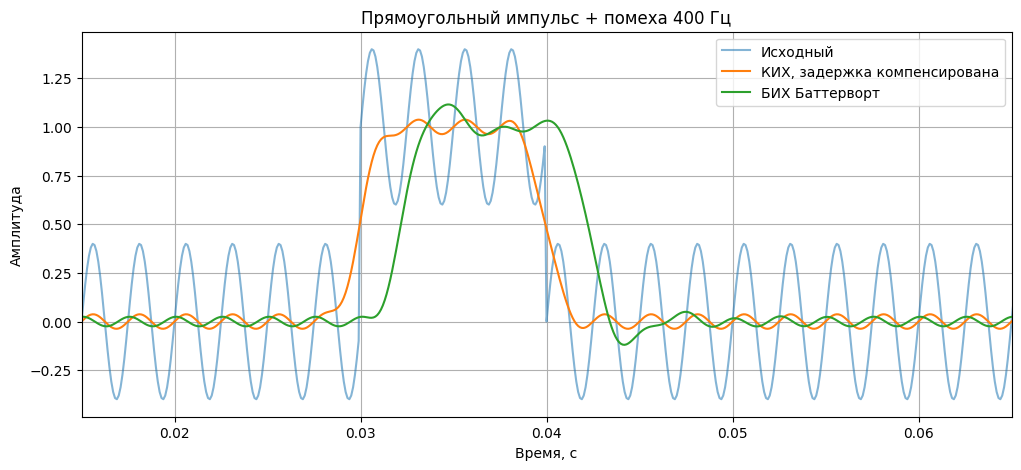

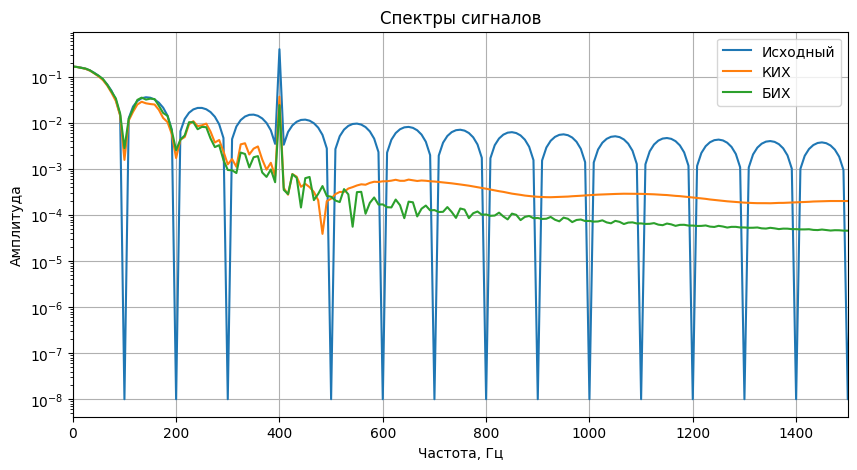

,Сигнал,Амплитуда 400 Гц
0,Исходный,0.4000
1,КИХ,0.0372
2,БИХ,0.0244


In [ ]:
fs_imp = 10000
fc_imp = 200
duration = 0.12
t = np.arange(0, duration, 1/fs_imp)

# Прямоугольный импульс длительностью 10 мс и синусоидальная помеха 400 Гц
pulse = ((t >= 0.03) & (t < 0.04)).astype(float)
interference = 0.4 * np.sin(2*np.pi*400*t)
x = pulse + interference

# Те же типы фильтров, что и в предыдущем пункте, но с новой частотой дискретизации
b_fir_imp = signal.firwin(51, fc_imp, window="hamming", fs=fs_imp)
sos_iir_imp = signal.butter(4, fc_imp, btype="low", fs=fs_imp, output="sos")

y_fir = signal.lfilter(b_fir_imp, [1], x)
y_iir = signal.sosfilt(sos_iir_imp, x)

# Для честного сравнения формы компенсируем постоянную задержку КИХ: (N-1)/2 отсчётов
fir_delay = (len(b_fir_imp) - 1) // 2
y_fir_aligned = np.r_[y_fir[fir_delay:], np.full(fir_delay, np.nan)]

plt.figure(figsize=(12, 5))
plt.plot(t, x, label="Исходный", alpha=0.55)
plt.plot(t, y_fir_aligned, label="КИХ, задержка компенсирована")
plt.plot(t, y_iir, label="БИХ Баттерворт")
plt.title("Прямоугольный импульс + помеха 400 Гц")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.xlim(0.015, 0.065)
plt.legend()
plt.show()

plt.figure()
for label, sig in [("Исходный", x), ("КИХ", np.nan_to_num(y_fir_aligned)), ("БИХ", y_iir)]:
    f, a = amp_spectrum(sig, fs_imp)
    plt.semilogy(f, np.maximum(a, 1e-8), label=label)
plt.title("Спектры сигналов")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.xlim(0, 1500)
plt.legend()
plt.show()

rows = []
for label, sig in [("Исходный", x), ("КИХ", np.nan_to_num(y_fir_aligned)), ("БИХ", y_iir)]:
    rows.append({
        "Сигнал": label,
        "Амплитуда 400 Гц": amp_at(sig, fs_imp, 400),
    })
display(pd.DataFrame(rows).round(4))


**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

**Ответ:** Форму импульса лучше сохраняет КИХ-фильтр, если компенсировать его постоянную групповую задержку: линейная фаза почти не деформирует фронты относительно друг друга. БИХ-фильтр Баттерворта 4го порядка обычно сильнее подавляет 400 Гц при этих параметрах и требует меньше вычислений, но из-за нелинейной фазы может заметнее искажать форму импульса и давать более выраженные переходные эффекты
